In [95]:
from __future__ import annotations
from rdkit import Chem

from rdkit.Chem import Mol
import itertools
from useful_rdkit_utils import get_largest_fragment
from rdkit.Chem.rdMMPA import FragmentMol
from tqdm import tqdm
from glob import glob

import py3Dmol
from exceptiongroup import catch
# Standard library imports
from pathlib import Path
from datetime import datetime
from typing import Optional, List, Iterable, Tuple, Dict, Any
import os
import re
import logging
import subprocess

# Third-party imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import yaml
import logging as logger
from itables import init_notebook_mode
from rdkit.Chem.Scaffolds.MurckoScaffold import MurckoScaffoldSmiles, MurckoScaffoldSmilesFromSmiles
from useful_rdkit_utils.useful_rdkit_utils import rdMolDescriptors

import plotly.graph_objects as go
from rdkit.Chem.Draw import IPythonConsole, MolsToGridImage
from rdkit.Chem import Descriptors
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from rdkit.Chem import PandasTools
import pandas as pd


init_notebook_mode(all_interactive=True)
# ---------------------------------------------------------------------------
print("Scoirng Analysis!")


Scoirng Analysis!


Index(['SMILES', 'Comment', 'RDKit_SMILES (REINVENT)', 'Score', 'SAScore',
       'DockingScore', 'SAScore (raw)', 'DockingScore (raw)', 'data_source'],
      dtype='object') Index(['Agent', 'Prior', 'Target', 'Score', 'SMILES', 'SMILES_state',
       'Input_SMILES', 'QED', 'QED (raw)', 'maize', 'maize (raw)',
       'Unwanted SMARTS', 'Unwanted SMARTS (raw)',
       'matchting_patterns (Unwanted SMARTS)', 'step', 'data_source'],
      dtype='object')
YESS
before:  38424
After selecting lowest 10% maize (raw) per Input_SMILES:  3849
after Further Refinement:  2488


/tmp/ipykernel_110674/2649019054.py:56: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  RL_df = RL_df.groupby('Input_SMILES', group_keys=False).apply(lowest_decile)


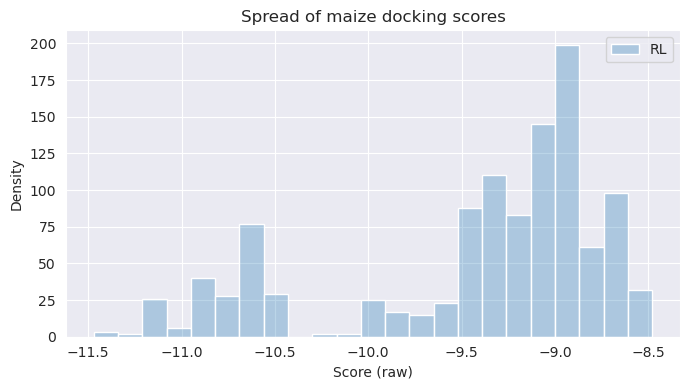

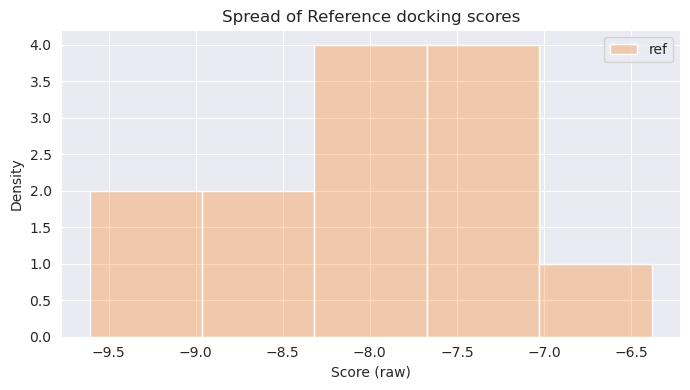

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [96]:
refs = pd.read_csv("/home/a/REINVENT4/ReinventStudies/scoringData/referenceData.csv", header=0)
cam833Input = "COc1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)CNC(=O)c2ccc3cc(F)ccc3n2)c(Cl)c1"

RL_df = pd.read_csv(
    "/home/a/REINVENT4/ReinventStudies/pleaseWork/justmol2mol_4_Compounds/graph-dock/node-reinvent/justmol2mol_4__1.csv",
    header=0)
refs['data_source'] = ['ref'] * len(refs)
RL_df['data_source'] = ['RL'] * len(RL_df)

# Build reference mapping: Input_SMILES -> DockingScore (raw) for data_source = ref
# Prefer explicit 'Input_SMILES' if present; otherwise fallback to 'SMILES'
ref_key_col = 'Input_SMILES' if 'Input_SMILES' in refs.columns else 'SMILES'
rl_key_col = 'Input_SMILES' if 'Input_SMILES' in RL_df.columns else 'SMILES'

print(refs.columns, RL_df.columns)


# Ensure required column exists in refs

def mergeDfsByScore(RL_df, refs, rl_key_col, ref_key_col):
    if 'DockingScore (raw)' in refs.columns and ref_key_col in refs.columns and rl_key_col in RL_df.columns:
        print("YESS")
        rl_tmp = RL_df.copy()
        rl_tmp = rl_tmp.merge(refs, left_on=['Input_SMILES'], right_on=['SMILES'], how='left', suffixes=('', '_ref'))
        return rl_tmp
    #
    #
    # rl_tmp


#
#
#
#     # Flag RL rows where its DockingScore (raw) <= matching ref DockingScore (raw)
#     if 'maize (raw)' in rl_tmp.columns:
#         RL_df['within_ref_maize'] = rl_tmp['maize (raw)'] <= rl_tmp['ref_docking_raw']
#         RL_df['matched_ref_maize_raw'] = rl_tmp['ref_docking_raw']
#     else:
#         RL_df['within_ref_maize'] = np.nan
#         RL_df['matched_ref_maize_raw'] = np.nan
# else:
#     # Columns missing; create placeholders
#     RL_df['within_ref_maize'] = np.nan
#     RL_df['matched_ref_maize_raw'] = np.nan
RL_df = mergeDfsByScore(RL_df, refs, "maize (raw)", "DockingScore (raw)")
print("before: ", len(RL_df))


# Keep only the lowest 10% maize (raw) per Unique Input_SMILES
def lowest_decile(group):
    # lower scores are better; select bottom 10% by value
    k = max(1, int(np.ceil(0.10 * len(group))))
    return group.nsmallest(k, columns='maize (raw)')


RL_df = RL_df.groupby('Input_SMILES', group_keys=False).apply(lowest_decile)
print("After selecting lowest 10% maize (raw) per Input_SMILES: ", len(RL_df))

RL_df = RL_df.loc[((RL_df['Unwanted SMARTS'] != 0) | RL_df['Score'] != 0)]
RL_df = RL_df.dropna(axis=0, subset=['Score'])
RL_df = RL_df.loc[(RL_df['QED'] >= 0.5)]
print("after Further Refinement: ", len(RL_df))
RL_df
RL_df = RL_df.loc[RL_df['maize (raw)'] <= RL_df['DockingScore (raw)']]
RL_df = RL_df.loc[((RL_df['Unwanted SMARTS'] != 0) | RL_df['Score'] != 0)]
RL_df = RL_df.dropna(axis=0, subset=['Score'])
RL_df = RL_df.loc[(RL_df['QED'] >= 0.5)]

# Visualize spread of maize (raw) scores for RL vs refs
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 4))
sns.histplot(data=RL_df, x='maize (raw)', label='RL', fill=True, alpha=0.3, linewidth=1)
plt.title('Spread of maize docking scores')
plt.xlabel('Score (raw)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
sns.histplot(data=refs, x='DockingScore (raw)', label='ref', fill=True, alpha=0.3, linewidth=1, color='tab:orange')
plt.title('Spread of Reference docking scores')
plt.xlabel('Score (raw)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

RL_df


In [97]:

sampling_multinomial_df = pd.read_csv("/home/a/REINVENT4/ReinventStudies/scoringData/samplingData/multinomial/cam833_Multinomial_Sampling.csv", header=0)
sampling_beamsearch_df = pd.read_csv("/home/a/REINVENT4/ReinventStudies/scoringData/samplingData/beamsearch/cam833_beamsearch_Sampling.csv", header=0)



sampling_multinomial_df['data_source'] = ['multinomial']*len(sampling_multinomial_df)
sampling_beamsearch_df['data_source'] = ['beamsearch']*len(sampling_beamsearch_df)

finalTotalDf = pd.concat([refs,RL_df, sampling_multinomial_df, sampling_beamsearch_df])
finalTotalDf

finalTotalDf

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [98]:

descriptor_names = list(rdMolDescriptors.Properties.GetAvailableProperties())

get_descriptors = rdMolDescriptors.Properties(descriptor_names)


def smi_to_descriptors(smile):
    mol = Chem.MolFromSmiles(smile)
    descriptors = []
    if mol:
        descriptors = np.array(get_descriptors.ComputeProperties(mol))
    return descriptors



outputDF = finalTotalDf[['SMILES', 'Input_SMILES', 'data_source']]
outputDF['descriptors'] = outputDF.SMILES.apply(smi_to_descriptors)
outputDF[descriptor_names] = pd.DataFrame(outputDF.descriptors.tolist(), index= outputDF.index)
outputDF.drop(columns=['descriptors'], inplace=True)

outputDF.drop_duplicates(subset=['SMILES'], inplace=True)
print(len(outputDF))
outputDF.head()

1522


/tmp/ipykernel_110674/486282710.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outputDF['descriptors'] = outputDF.SMILES.apply(smi_to_descriptors)
/tmp/ipykernel_110674/486282710.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outputDF[descriptor_names] = pd.DataFrame(outputDF.descriptors.tolist(), index= outputDF.index)
/tmp/ipykernel_110674/486282710.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [99]:
from rdkit.Chem.rdMolDescriptors import GetMorganFingerprintAsBitVect

outputDF['NumRotatableBonds'] = outputDF['NumRotatableBonds'].astype(int)
outputDF['mol'] = outputDF['SMILES'].apply(Chem.MolFromSmiles)


outputDF["ro5"] = [False]*len(outputDF)
outputDF["ro3"] = [False]*len(outputDF)

outputDF.loc[((outputDF['exactmw']<=500) & (outputDF['NumHBA']<=10) & (outputDF['NumHBD'] <= 5)), "ro5"] = True
outputDF.loc[((outputDF['exactmw']<=300) & (outputDF['NumHBA']<=3) & (outputDF['NumHBD'] <= 3) & (outputDF['NumRotatableBonds'] <= 3)), "ro3"] = True



print(len(outputDF[outputDF["ro5"]==True]))
print(len(outputDF[outputDF["ro3"]==True]))


1503
5


In [100]:
from rdkit.Chem import AllChem, DataStructs

# fps_2048 = [fp_gen.GetFingerprint(lig) for lig in outputDF['mol']]
cam833_fps_2048 = AllChem.GetMorganFingerprintAsBitVect(Chem.MolFromSmiles(cam833Input),
     radius=2, nBits=1024, useFeatures=True
)

[20:42:14] DEPRECATION WARNING: please use MorganGenerator


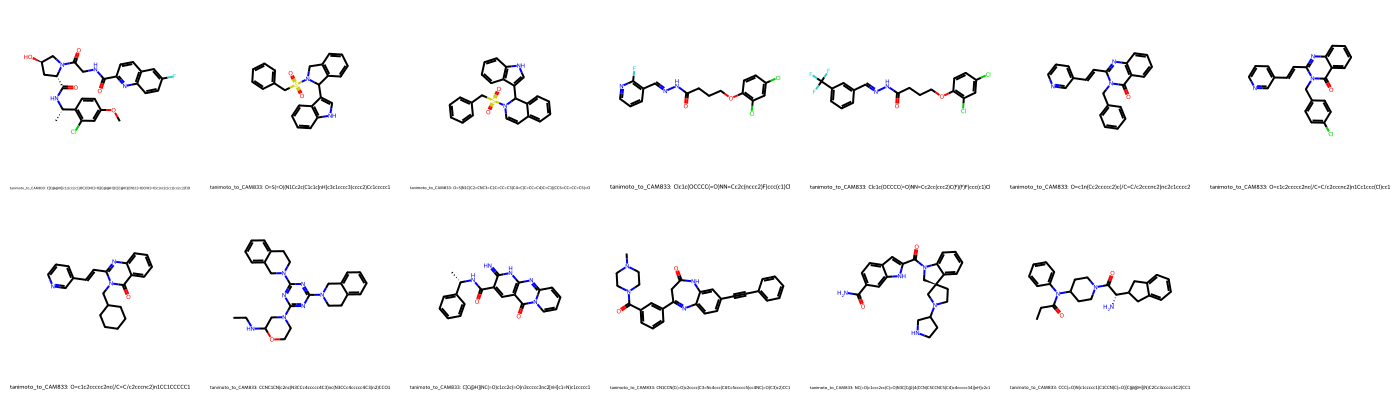

In [101]:


img = MolsToGridImage(
    outputDF.loc[outputDF['data_source']=='ref']['mol'],
    subImgSize=(200, 200),
    molsPerRow=7,
    maxMols=49,
    legends=[f"tanimoto_to_CAM833: {row['SMILES']}" for _, row in outputDF.loc[outputDF['data_source']=='ref'].iterrows()], useSVG=False,
returnPNG=True)
img


In [102]:
outputDF

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [103]:
from rdkit.Chem import MACCSkeys, rdFingerprintGenerator

REF_MOL = Chem.MolFromSmiles(cam833Input)
# maccs_REF = MACCSkeys.GenMACCSKeys(REF_MOL)
#
# outputDF["maccs"] = outputDF.mol.apply(MACCSkeys.GenMACCSKeys)

# molecule_list = outputDF["maccs"].to_list()

fpg = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
morgan_ref  = fpg.GetCountFingerprint(REF_MOL)

outputDF["morgan"] = outputDF["mol"].map(fpg.GetCountFingerprint)
morgan_list = outputDF["morgan"].to_list()


outputDF["tanimoto_morgan"] = DataStructs.BulkTanimotoSimilarity(morgan_ref, morgan_list)
outputDF["dice_morgan"] = DataStructs.BulkDiceSimilarity(morgan_ref, morgan_list)

/home/a/miniconda3/envs/maize-dev/lib/python3.10/site-packages/rdkit/Chem/Draw/IPythonConsole.py:261: UserWarning: Truncating the list of molecules to be displayed to 49. Change the maxMols value to display more.
  warnings.warn(


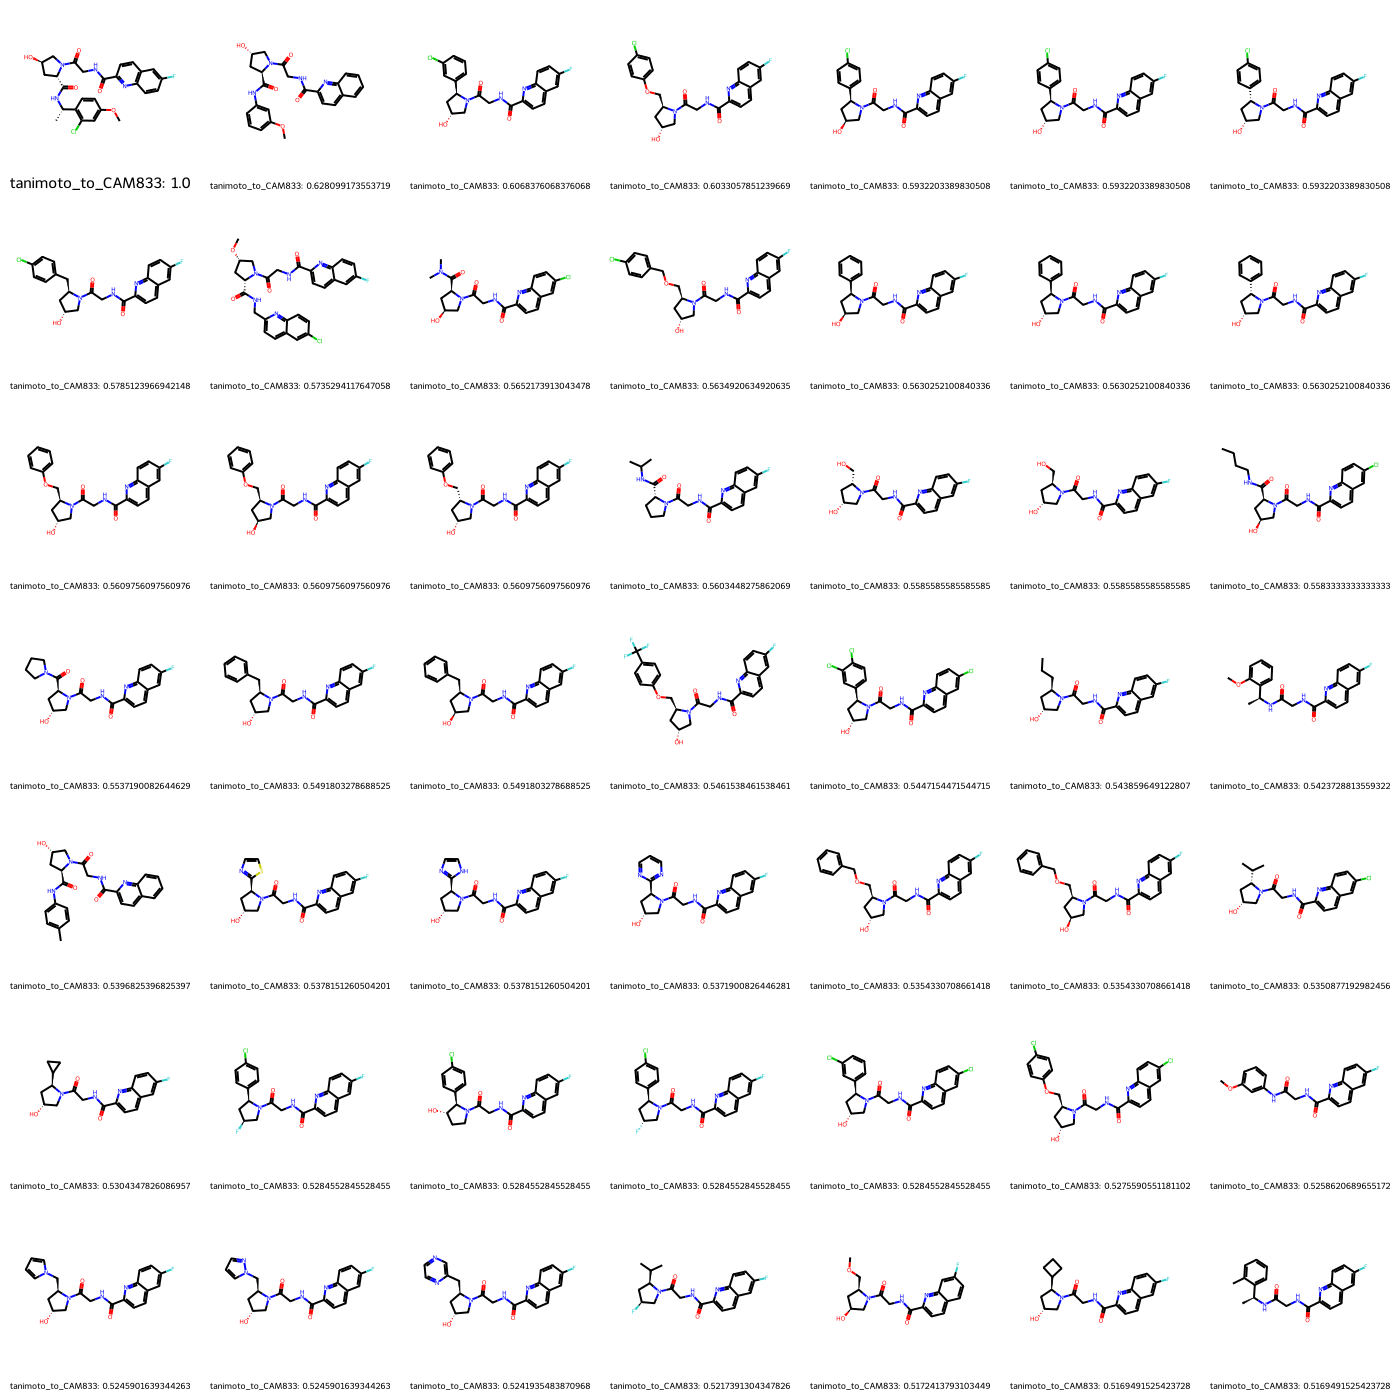

In [104]:
temp = outputDF.sort_values(by="tanimoto_morgan", ascending=False).head(50)
img = MolsToGridImage(
    temp['mol'],
    subImgSize=(200, 200),
    molsPerRow=7,
    maxMols=49,
    legends=[f"tanimoto_to_CAM833: {row['tanimoto_morgan']}" for _, row in temp.iterrows()], useSVG=False,
returnPNG=True)
img


In [105]:
from rdkit.Chem.rdfiltercatalog import FilterCatalogParams, FilterCatalog

params = FilterCatalogParams()
params.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS)
catalog = FilterCatalog(params)


matches = []
clean = []
for index, row in tqdm(outputDF.iterrows(), total=outputDF.shape[0]):
    molecule =row['mol']
    entries = catalog.GetFirstMatch(molecule)
    if entries is not None:
        # store PAINS information
        painsList = []
        matches.append(
            {
                "SMILES": row['SMILES'],
                "mol": molecule,
                "pains":entries.GetDescription().capitalize(),
            }
        )
        outputDF.at[index, 'RD_PAINS_Pass'] = False
    else:
        # collect indices of molecules without PAINS
        clean.append(index)
        outputDF.at[index, 'RD_PAINS_Pass'] = True


matches = pd.DataFrame(matches)
outputDF_clean = outputDF.loc[outputDF['RD_PAINS_Pass']==True]

print(f"Number of compounds with PAINS: {len(matches)}")
print(f"Number of compounds without PAINS: {len(outputDF_clean)}")

matches.to_csv("scoringData/samplingData/unwanted_substructures.csv")


100%|██████████| 1522/1522 [00:05<00:00, 294.33it/s]

Number of compounds with PAINS: 44
Number of compounds without PAINS: 1483


In [106]:
substructures = pd.read_csv("scoringData/samplingData/unwanted_substructures.csv")
substructures = substructures.rename(columns={"SMILEs": "SMILES"})
substructures

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


Number of unwanted substructures in collection: 44


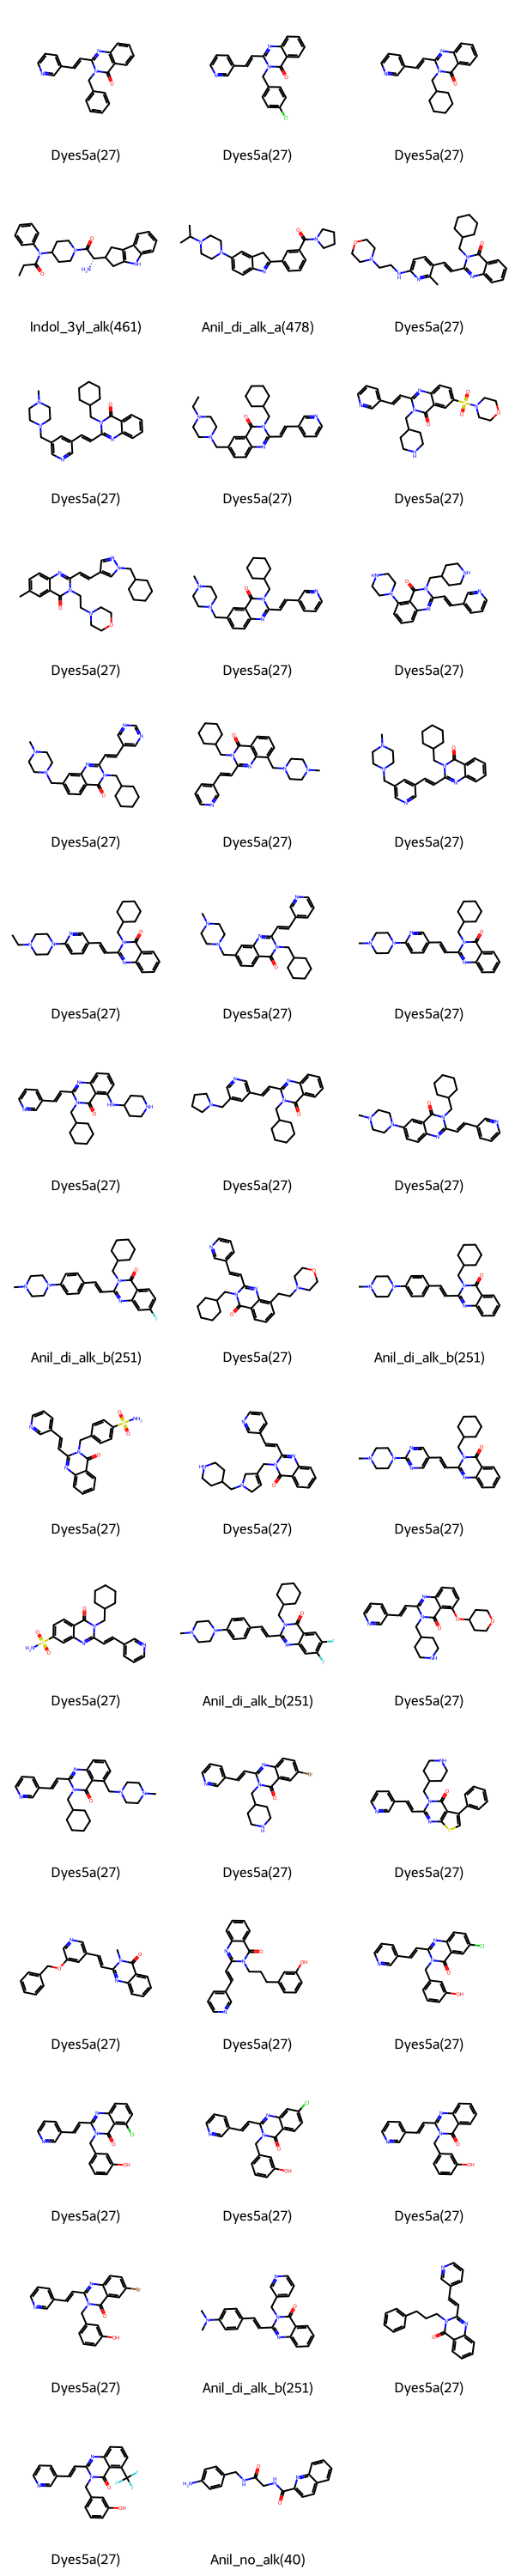

In [107]:

substructures["mol"] = substructures['SMILES'].apply(Chem.MolFromSmiles)
print("Number of unwanted substructures in collection:", len(substructures))
Chem.Draw.MolsToGridImage(
    mols=substructures.mol.tolist(),
    legends=substructures.pains.tolist(),
)

In [108]:

matches = []
clean = []
for index, row in tqdm(outputDF_clean.iterrows(), total=outputDF_clean.shape[0]):
    molecule = Chem.MolFromSmiles(row.SMILES)
    match = False
    for _, substructure in substructures.iterrows():
        if molecule.HasSubstructMatch(substructure.mol):
            matches.append(
                {
                    "mol": molecule,
                    "substructure": substructure.mol,
                    "substructure_name": substructure["pains"],
                }
            )
            match = True
    if not match:
        clean.append(index)

matches = pd.DataFrame(matches)
outputFinalDF = outputDF_clean.loc[clean]

100%|██████████| 1483/1483 [00:04<00:00, 356.72it/s]


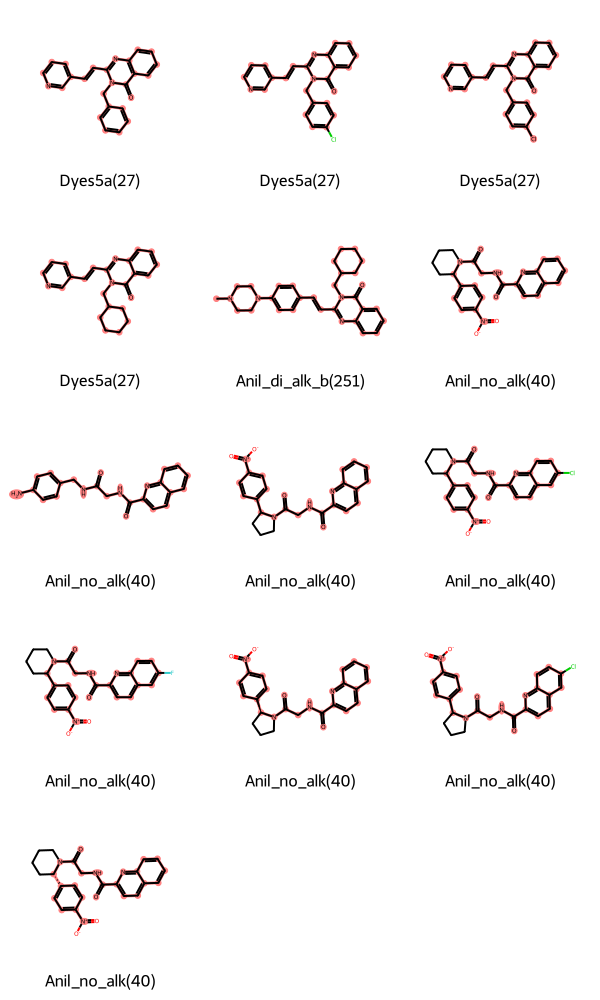

In [109]:
to_highlight = [
    row.mol.GetSubstructMatch(row.substructure) for _, row in matches.head(20).iterrows()
]
Chem.Draw.MolsToGridImage(
    list(matches.head(20).mol),
    highlightAtomLists=to_highlight,
    legends=list(matches.head(20).substructure_name),
)

In [110]:
# NBVAL_CHECK_OUTPUT
groups = matches.groupby("substructure_name")
group_frequencies = groups.size()
group_frequencies.sort_values(ascending=False, inplace=True)
group_frequencies.head(10)
outputFinalDF

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [111]:
outputDF_clean = outputFinalDF

ro5_df = outputFinalDF.loc[outputFinalDF["ro5"] == True].sort_values(by="tanimoto_morgan", ascending=False)
ro3_df = outputFinalDF.loc[outputFinalDF["ro3"] == True].sort_values(by="tanimoto_morgan", ascending=False)

ro3_df = ro3_df.drop_duplicates(subset=['SMILES'])
ro5_df = ro5_df.drop_duplicates(subset=['SMILES'])

print(f"Ro3_DF length: {len(ro3_df)}")
print(f"Ro5_DF length: {len(ro5_df)}")

outputFinalDF


Ro3_DF length: 5
Ro5_DF length: 1459


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


Computing pairwise distances: 100%|██████████| 1458/1458 [00:01<00:00, 864.74it/s]


Selected cutoff (heuristic): 0.6
Number of clusters: 20
Cluster sizes summary -> min: 1, median: 2.5, mean: 72.95, max: 1092, singletons: 5


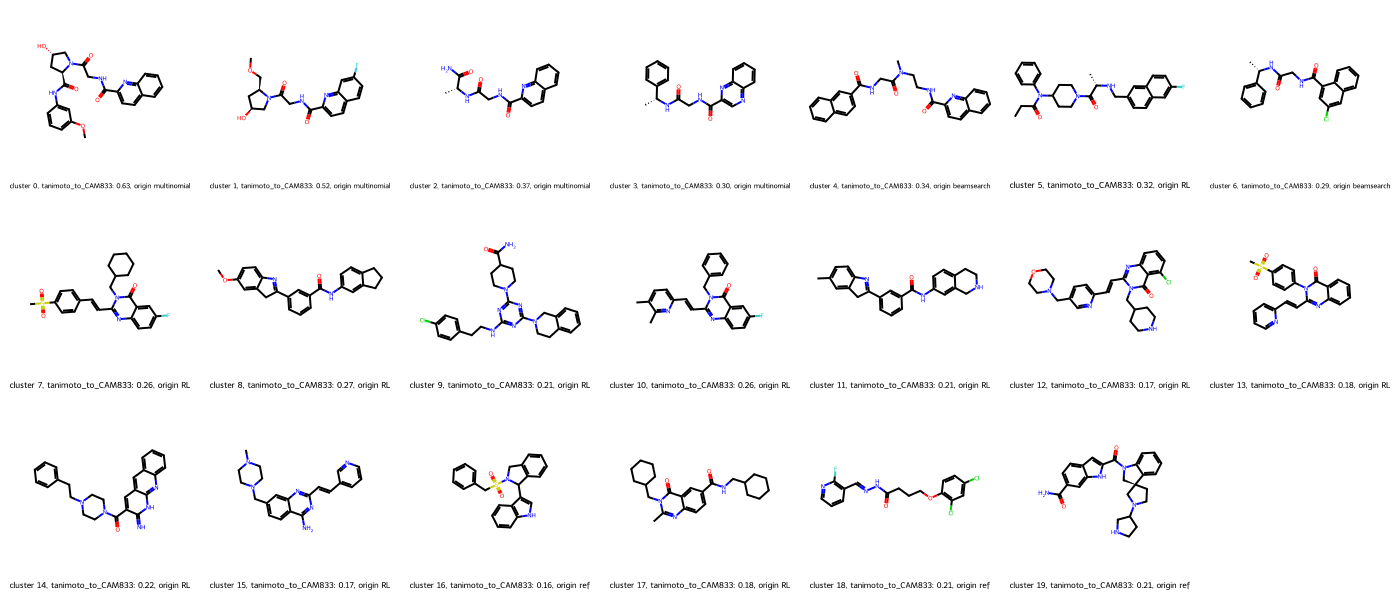

In [112]:
# Cluster ro5_df using existing 'morgan' fingerprints with a progress bar, then visualize representatives

from rdkit.ML.Cluster import Butina
from rdkit import DataStructs
from tqdm import tqdm

# Ensure valid molecules and fingerprints
ro5_df = ro5_df.dropna(subset=["mol", "morgan"]).reset_index(drop=True)
fps = ro5_df["morgan"].tolist()  # UIntSparseIntVect (count fingerprints)

# Compute distance matrix with progress bar
dists = []
for i in tqdm(range(1, len(fps)), desc="Computing pairwise distances"):
    sims = DataStructs.BulkTanimotoSimilarity(fps[i], fps[:i])
    dists.extend([1 - x for x in sims])

# Explore multiple cutoffs to find an "ideal" number of clusters via elbow on cluster count and singleton ratio
cutoffs = [round(x, 2) for x in list(np.linspace(0.2, 0.6, 9))]
stats = []
for c in cutoffs:
    cls = Butina.ClusterData(dists, len(fps), c, isDistData=True)
    sizes = [len(x) for x in cls]
    n_clusters = len(cls)
    n_singletons = sum(1 for s in sizes if s == 1)
    mean_size = np.mean(sizes) if sizes else 0
    median_size = np.median(sizes) if sizes else 0
    max_size = max(sizes) if sizes else 0
    stats.append({
        "cutoff": c,
        "n_clusters": n_clusters,
        "n_singletons": n_singletons,
        "singleton_ratio": (n_singletons / n_clusters) if n_clusters else 0,
        "mean_size": mean_size,
        "median_size": median_size,
        "max_size": max_size
    })
cluster_stats_df = pd.DataFrame(stats)
cluster_stats_df

# Heuristic: choose cutoff minimizing (normalized n_clusters + normalized singleton_ratio)
if len(cluster_stats_df) > 0:
    norm_clusters = (cluster_stats_df["n_clusters"] - cluster_stats_df["n_clusters"].min()) / max(1e-9, (
                cluster_stats_df["n_clusters"].max() - cluster_stats_df["n_clusters"].min()))
    norm_singletons = (cluster_stats_df["singleton_ratio"] - cluster_stats_df["singleton_ratio"].min()) / max(1e-9, (
                cluster_stats_df["singleton_ratio"].max() - cluster_stats_df["singleton_ratio"].min()))
    score = norm_clusters + norm_singletons
    best_idx = int(score.idxmin())
    cutoff = float(cluster_stats_df.loc[best_idx, "cutoff"])
else:
    cutoff = 0.3

print(f"Selected cutoff (heuristic): {cutoff}")

# Cluster with Butina using selected cutoff
clusters = Butina.ClusterData(dists, len(fps), cutoff, isDistData=True)

# Per-cluster statistics at selected cutoff
sizes = [len(x) for x in clusters]
print(f"Number of clusters: {len(clusters)}")
print(
    f"Cluster sizes summary -> min: {min(sizes) if sizes else 0}, median: {np.median(sizes) if sizes else 0}, mean: {np.mean(sizes) if sizes else 0:.2f}, max: {max(sizes) if sizes else 0}, singletons: {sum(1 for s in sizes if s == 1)}")

# Assign cluster ids
cluster_ids = {}
for cid, members in enumerate(clusters):
    for idx in members:
        cluster_ids[idx] = cid
ro5_df = ro5_df.copy()
ro5_df["cluster_id"] = [cluster_ids.get(i, -1) for i in range(len(ro5_df))]

# Representatives: first member per cluster
rep_indices = [min(list(c)) for c in clusters] if clusters else []
reps = ro5_df.iloc[rep_indices] if rep_indices else ro5_df.iloc[[]]

img = MolsToGridImage(
    reps['mol'],
    subImgSize=(200, 200),
    molsPerRow=7,
    maxMols=49,
    legends=[
        f"cluster {row['cluster_id']}, tanimoto_to_CAM833: {row['tanimoto_morgan']:.2f}, origin {row['data_source']}"
        for _, row in reps.iterrows()],
    useSVG=True
)

img


Computing pairwise distances (RO3): 100%|██████████| 4/4 [00:00<00:00, 22429.43it/s]

Selected cutoff for RO3 (heuristic): 0.5
Number of RO3 clusters: 1
RO3 Cluster sizes -> min: 5, median: 5.0, mean: 5.00, max: 5, singletons: 0


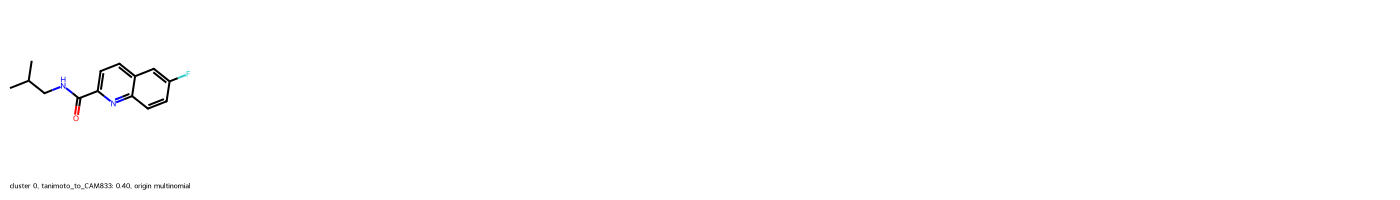

In [113]:
# Cluster ro3_df using existing 'morgan' fingerprints with a progress bar, then visualize representatives

from rdkit.ML.Cluster import Butina
from rdkit import DataStructs
from tqdm import tqdm

# Ensure valid molecules and fingerprints
ro3_df = ro3_df.dropna(subset=["mol", "morgan"]).reset_index(drop=True)
fps = ro3_df["morgan"].tolist()  # UIntSparseIntVect (count fingerprints)

# Compute distance matrix with progress bar
dists = []
for i in tqdm(range(1, len(fps)), desc="Computing pairwise distances (RO3)"):
    sims = DataStructs.BulkTanimotoSimilarity(fps[i], fps[:i])
    dists.extend([1 - x for x in sims])

# Explore multiple cutoffs to find an "ideal" number of clusters via elbow on cluster count and singleton ratio
cutoffs = [round(x, 2) for x in list(np.linspace(0.2, 0.6, 9))]
stats = []
for c in cutoffs:
    cls = Butina.ClusterData(dists, len(fps), c, isDistData=True)
    sizes = [len(x) for x in cls]
    n_clusters = len(cls)
    n_singletons = sum(1 for s in sizes if s == 1)
    mean_size = np.mean(sizes) if sizes else 0
    median_size = np.median(sizes) if sizes else 0
    max_size = max(sizes) if sizes else 0
    stats.append({
        "cutoff": c,
        "n_clusters": n_clusters,
        "n_singletons": n_singletons,
        "singleton_ratio": (n_singletons / n_clusters) if n_clusters else 0,
        "mean_size": mean_size,
        "median_size": median_size,
        "max_size": max_size
    })
cluster_stats_df_ro3 = pd.DataFrame(stats)
cluster_stats_df_ro3

# Heuristic: choose cutoff minimizing (normalized n_clusters + normalized singleton_ratio)
if len(cluster_stats_df_ro3) > 0:
    norm_clusters = (cluster_stats_df_ro3["n_clusters"] - cluster_stats_df_ro3["n_clusters"].min()) / max(1e-9, (
            cluster_stats_df_ro3["n_clusters"].max() - cluster_stats_df_ro3["n_clusters"].min()))
    norm_singletons = (cluster_stats_df_ro3["singleton_ratio"] - cluster_stats_df_ro3["singleton_ratio"].min()) / max(
        1e-9, (
                cluster_stats_df_ro3["singleton_ratio"].max() - cluster_stats_df_ro3["singleton_ratio"].min()))
    score = norm_clusters + norm_singletons
    best_idx = int(score.idxmin())
    cutoff_ro3 = float(cluster_stats_df_ro3.loc[best_idx, "cutoff"])
else:
    cutoff_ro3 = 0.3

print(f"Selected cutoff for RO3 (heuristic): {cutoff_ro3}")

# Cluster with Butina using selected cutoff
clusters_ro3 = Butina.ClusterData(dists, len(fps), cutoff_ro3, isDistData=True)

# Per-cluster statistics at selected cutoff
sizes = [len(x) for x in clusters_ro3]
print(f"Number of RO3 clusters: {len(clusters_ro3)}")
print(
    f"RO3 Cluster sizes -> min: {min(sizes) if sizes else 0}, median: {np.median(sizes) if sizes else 0}, mean: {np.mean(sizes) if sizes else 0:.2f}, max: {max(sizes) if sizes else 0}, singletons: {sum(1 for s in sizes if s == 1)}")

# Assign cluster ids
cluster_ids = {}
for cid, members in enumerate(clusters_ro3):
    for idx in members:
        cluster_ids[idx] = cid
ro3_df = ro3_df.copy()
ro3_df["cluster_id"] = [cluster_ids.get(i, -1) for i in range(len(ro3_df))]

# Representatives: first member per cluster
rep_indices = [min(list(c)) for c in clusters_ro3] if clusters_ro3 else []
reps_ro3 = ro3_df.iloc[rep_indices] if rep_indices else ro3_df.iloc[[]]

img = MolsToGridImage(
    reps_ro3['mol'],
    subImgSize=(200, 200),
    molsPerRow=7,
    maxMols=49,
    legends=[
        f"cluster {row['cluster_id']}, tanimoto_to_CAM833: {row['tanimoto_morgan']:.2f}, origin {row['data_source']}"
        for _, row in reps_ro3.iterrows()],
    useSVG=True
)

img


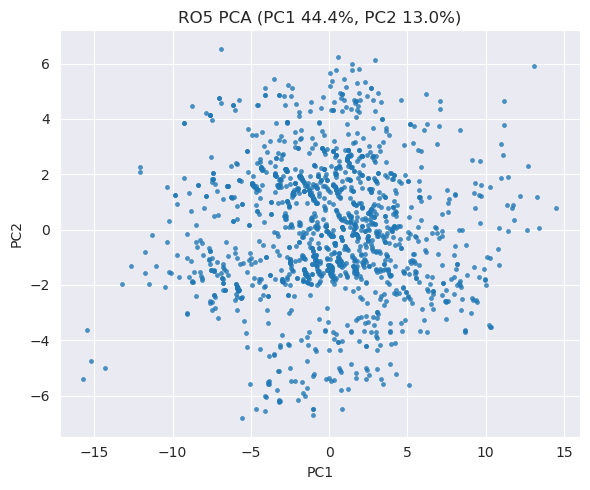

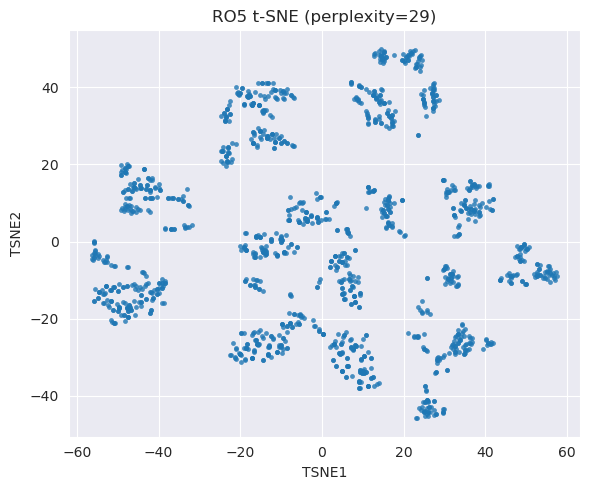

/home/a/miniconda3/envs/maize-dev/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


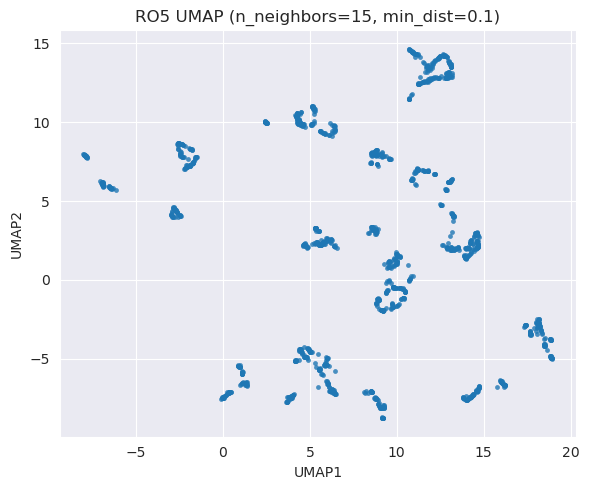

In [114]:
# PCA, t-SNE, and UMAP on ro5_df numeric descriptors; no cluster coloring

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure required packages are available
try:
    from sklearn.decomposition import PCA
    from sklearn.manifold import TSNE
    from sklearn.preprocessing import StandardScaler
except ImportError:
    !pip install scikit-learn
    from sklearn.decomposition import PCA
    from sklearn.manifold import TSNE
    from sklearn.preprocessing import StandardScaler

# UMAP may be missing; install if needed
try:
    import umap
except ImportError:
    !pip install umap-learn
    import umap

# Guard: need ro5_df
if "ro5_df" in globals() and isinstance(ro5_df, pd.DataFrame):
    meta_cols = {"SMILES", "Input_SMILES", "data_source", "mol", "morgan", "ro5", "ro3", "RD_PAINS_Pass", "cluster_id"}
    numeric_cols = [c for c in ro5_df.columns
                    if c not in meta_cols and (np.issubdtype(ro5_df[c].dtype, np.number))]
    X = ro5_df[numeric_cols].replace([np.inf, -np.inf], np.nan).dropna(axis=0)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X.values)

    # PCA
    pca = PCA(n_components=2, random_state=0)
    pca_2d = pca.fit_transform(X_scaled)
    pca_df = pd.DataFrame(pca_2d, columns=["PC1", "PC2"], index=X.index)

    plt.figure(figsize=(6, 5))
    sns.scatterplot(data=pca_df, x="PC1", y="PC2", color="#1f77b4", s=12, alpha=0.8, linewidth=0)
    plt.title(
        f"RO5 PCA (PC1 {pca.explained_variance_ratio_[0] * 100:.1f}%, PC2 {pca.explained_variance_ratio_[1] * 100:.1f}%)")
    plt.tight_layout()
    plt.show()

    # t-SNE
    perplexity = max(5, min(30, (len(X_scaled) // 50) or 5))
    tsne = TSNE(n_components=2, perplexity=perplexity, learning_rate="auto", init="pca", random_state=0)
    tsne_2d = tsne.fit_transform(X_scaled)
    tsne_df = pd.DataFrame(tsne_2d, columns=["TSNE1", "TSNE2"], index=X.index)

    plt.figure(figsize=(6, 5))
    sns.scatterplot(data=tsne_df, x="TSNE1", y="TSNE2", color="#1f77b4", s=12, alpha=0.8, linewidth=0)
    plt.title(f"RO5 t-SNE (perplexity={perplexity})")
    plt.tight_layout()
    plt.show()

    # UMAP
    umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=0)
    umap_2d = umap_model.fit_transform(X_scaled)
    umap_df = pd.DataFrame(umap_2d, columns=["UMAP1", "UMAP2"], index=X.index)

    plt.figure(figsize=(6, 5))
    sns.scatterplot(data=umap_df, x="UMAP1", y="UMAP2", color="#1f77b4", s=12, alpha=0.8, linewidth=0)
    plt.title("RO5 UMAP (n_neighbors=15, min_dist=0.1)")
    plt.tight_layout()
    plt.show()


In [115]:
# What to look for:
# - PCA: broad global patterns; if points spread along PC1/PC2, descriptors separate chemotypes.
# - t-SNE: local structure; tight islands imply similar property profiles.
# - UMAP: continuity and neighborhoods; bridges hint at gradients across RO5 space.

outputFinalDF.to_csv("scoringData/SmilesForEvaluation.csv", index=False)

with open("scoringData/SmilesForEvaluation.smi", "w") as file:
    for smi in outputFinalDF['SMILES']:
        print(smi)
        file.write(f"{smi}\n")


C[C@@H](c1c(cc(cc1)OC)Cl)NC(=O)[C@@H]1C[C@H](CN1C(=O)CNC(=O)c1nc2c(cc1)cc(cc2)F)O
O=C(NCC(=O)N1CCCCC1)c1ccc2cc(Cl)ccc2n1
O=S(=O)(N1Cc2c(C1c1c[nH]c3c1cccc3)cccc2)Cc1ccccc1
CN(CCNC(=O)CNC(=O)c1ccc2cc(Cl)ccc2n1)c1ccccc1
O=S(N1C(C2=CNC3=C2C=CC=C3)C4=C(C=CC=C4)C=C1)(CC5=CC=CC=C5)=O
O=C(NCC(=O)N1CCCCC1Cc1ccccc1)c1ccc2ccccc2n1
Clc1c(OCCCC(=O)NN=Cc2c(nccc2)F)ccc(c1)Cl
O=C(NCC(=O)N1CCCCC1c1ccc(F)cc1)c1ccc2cc(Cl)ccc2n1
Clc1c(OCCCC(=O)NN=Cc2cc(ccc2)C(F)(F)F)ccc(c1)Cl
O=C(NCC(=O)N1CCC1C1CCCCC1)c1ccc2cc(F)ccc2n1
CCNC1CN(c2nc(N3CCc4ccccc4C3)nc(N3CCc4ccccc4C3)n2)CCO1
O=C(NCC(=O)N1CCCCC1c1ccc(Cl)cc1)c1ccc2ccccc2n1
C[C@H](NC(=O)c1cc2c(=O)n3ccccc3nc2[nH]c1=N)c1ccccc1
CC(NC(=O)CNC(=O)c1ccc2ccccc2n1)c1ccc(OC2CCCC2)cc1
CN1CCN(C(=O)c2cccc(C3=Nc4ccc(C#Cc5ccccc5)cc4NC(=O)C3)c2)CC1
O=C(NCC(=O)N1C[C@H](O)C[C@H]1COc1ccccc1)c1ccc2cc(Cl)ccc2n1
NC(=O)c1ccc2cc(C(=O)N3C[C@]4(CCN(C5CCNC5)C4)c4ccccc34)[nH]c2c1
O=C(NCC(=O)N1CCC2(CCNC2)C1)c1ccc2cc(Cl)ccc2n1
CCC(=O)N(c1ccccc1)C1CCN(C(=O)[C@@H](N)C2Cc3ccccc3C2)CC1
O=C(NCC(

In [116]:




# Python
from rdkit import Chem
import pandas as pd

# Use your DataFrame with a 'SMILES' column
df = outputFinalDF.copy()

def connectivity_key_no_std(smi: str) -> str | None:
    """Connectivity-only key: drop stereo and isotopes; keep charges/tautomers as-is."""
    if not isinstance(smi, str):
        return None
    mol = Chem.MolFromSmiles(smi, sanitize=True)
    if mol is None:
        return None
    # Remove stereochemistry (collapses stereoisomers)
    Chem.RemoveStereochemistry(mol)
    # Remove isotopes
    for a in mol.GetAtoms():
        a.SetIsotope(0)
    # Non-isomeric canonical SMILES as key
    return Chem.MolToSmiles(mol, isomericSmiles=False, canonical=True)

# Build keys
df = df.copy()
df["connectivity_key"] = df["SMILES"].map(connectivity_key_no_std)
df_valid = df.dropna(subset=["connectivity_key"]).copy()

# Keep one representative per connectivity key
reduced = df_valid.drop_duplicates(subset=["connectivity_key"], keep="first").copy()

print(f"Original: {len(df)}  Reduced: {len(reduced)}  Unique connectivity groups: {df_valid['connectivity_key'].nunique()}")
reduced

Original: 1917  Reduced: 1188  Unique connectivity groups: 1188


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [117]:
reduced = reduced.loc[reduced['ro5']==True]
# Write reduced SMILES for docking
out_smi = "scoringData/SmilesForDocking_reduced.smi"
with open(out_smi, "w") as f:
    for s in reduced["SMILES"]:
        f.write(s + "\n")
print(f"Wrote {len(reduced)} SMILES to {out_smi}")

# Optional: mapping from representative to collapsed members
members = df_valid.groupby("connectivity_key")["SMILES"].apply(list).rename("collapsed_members")
map_df = reduced[["SMILES", "connectivity_key"]].merge(members, on="connectivity_key", how="left")
map_df.to_csv("scoringData/reduced_connectivity_mapping.csv", index=False)
print("Saved mapping to scoringData/reduced_connectivity_mapping.csv")

Wrote 1169 SMILES to scoringData/SmilesForDocking_reduced.smi
Saved mapping to scoringData/reduced_connectivity_mapping.csv
